# Métricas do modelo GoogleNet para o Plantvillage

Abrindo dataset

In [5]:
import pandas as pd

df = pd.read_csv('Dataset/processed/plantvillage_data.csv')
df

,Unnamed: 0,file_path,version,class,plant,disease
0,0,Dataset\plantvillage_dataset\segmented\Apple__...,segmented,Apple___Apple_scab,Apple,Apple_scab
1,1,Dataset\plantvillage_dataset\segmented\Apple__...,segmented,Apple___Apple_scab,Apple,Apple_scab
2,2,Dataset\plantvillage_dataset\segmented\Apple__...,segmented,Apple___Apple_scab,Apple,Apple_scab
3,3,Dataset\plantvillage_dataset\segmented\Apple__...,segmented,Apple___Apple_scab,Apple,Apple_scab
4,4,Dataset\plantvillage_dataset\segmented\Apple__...,segmented,Apple___Apple_scab,Apple,Apple_scab
...,...,...,...,...,...,...
325825,325825,Dataset\plantvillage_dataset\color\Tomato___To...,color,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato,Tomato_Yellow_Leaf_Curl_Virus
325826,325826,Dataset\plantvillage_dataset\color\Tomato___To...,color,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato,Tomato_Yellow_Leaf_Curl_Virus
325827,325827,Dataset\plantvillage_dataset\color\Tomato___To...,color,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato,Tomato_Yellow_Leaf_Curl_Virus
325828,325828,"Dataset\plantvillage_dataset\grayscale\Pepper,...",grayscale,"Pepper,_bell___healthy","Pepper,_bell",healthy


Extraíndo caminhos das imagens e rótulos

In [6]:
caminhos_imagens = df['file_path'].values
rotulos = df['class'].values

Importando label enconder

In [ ]:
import joblib

label_encoder = joblib.load('labelencoder_googlenet_plantvillage.pkl')
label_encoder

Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Holds the label for each class.","ndarray[object](38,)","['Apple___Apple_scab','Apple___Black_rot','Apple___Cedar_apple_rust',..., 'Tomato___Tomato_Yellow_Leaf_Curl_Virus','Tomato___Tomato_mosaic_virus', 'Tomato___healthy']"


Convertendo rótulos de texto para número

In [13]:
rotulos_inteiros = label_encoder.transform(rotulos)
num_classes = len(label_encoder.classes_)
print(rotulos_inteiros)
print(num_classes)

[ 0  0  0 ... 35 19 19]
38


Dividindo em conjunto de treino e conjunto de teste

In [14]:
from sklearn.model_selection import train_test_split

x_treino, x_val, y_treino, y_val = train_test_split(
    caminhos_imagens,
    rotulos_inteiros,
    test_size=0.2,
    random_state=1024,
    stratify=rotulos_inteiros
)

Definindo constantes

In [19]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

Definindo função para pré-processamento das imagens

In [20]:
import tensorflow as tf

def processar_imagem_googlenet(caminho, rotulo):
    # Lendo a imagem do disco
    img = tf.io.read_file(caminho)

    # Decodificando o JPEG (assume que seja .jpg)
    img = tf.io.decode_jpeg(img, channels=3)

    # Redimensionando imagem para 224x224
    img = tf.image.resize(img, IMG_SIZE)

    # Normalizando os pixels para o intervalo entre 0 e 1
    img = img / 255.0

    return img, (rotulo, rotulo, rotulo)

Criando dataset do tensorflow

In [21]:
ds_val = tf.data.Dataset.from_tensor_slices((x_val, y_val))
ds_val = ds_val.map(processar_imagem_googlenet, num_parallel_calls=AUTOTUNE)
ds_val = ds_val.batch(BATCH_SIZE).prefetch(AUTOTUNE)

Importando modelo

In [23]:
model = tf.keras.models.load_model('modelo_googlenet_plantvillage.keras')
model

<Functional name=GoogleNet, built=True>

Obtendo métricas

In [40]:
predicoes = model.predict(ds_val)

2037/2037 ━━━━━━━━━━━━━━━━━━━━ 693s 340ms/step


Gerando matriz de confusão

In [41]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Pegando apenas a saída pricipal
predicao_principal = predicoes[0]

# Convertendo as probabilidades em classes (índices inteiros)
y_pred = np.argmax(predicao_principal, axis=1)

# Extraíndo os rótulos reais (y_true) do dataset de validação
# Precisamos disso porque o ds_val retorna a imagem e uma tupla de 3 rótulos (devido aos 3 outputs)
y_true = []
for imagens, (rotulo_main, rotulo_aux1, rotulo_aux2) in ds_val.unbatch():
    # Pegamos apenas o primeiro rótulo da tupla, que corresponde ao main_output
    y_true.append(rotulo_main.numpy())
y_true = np.array(y_true)

# Gerando matriz de confusão
matriz_confusao = confusion_matrix(y_true, y_pred)


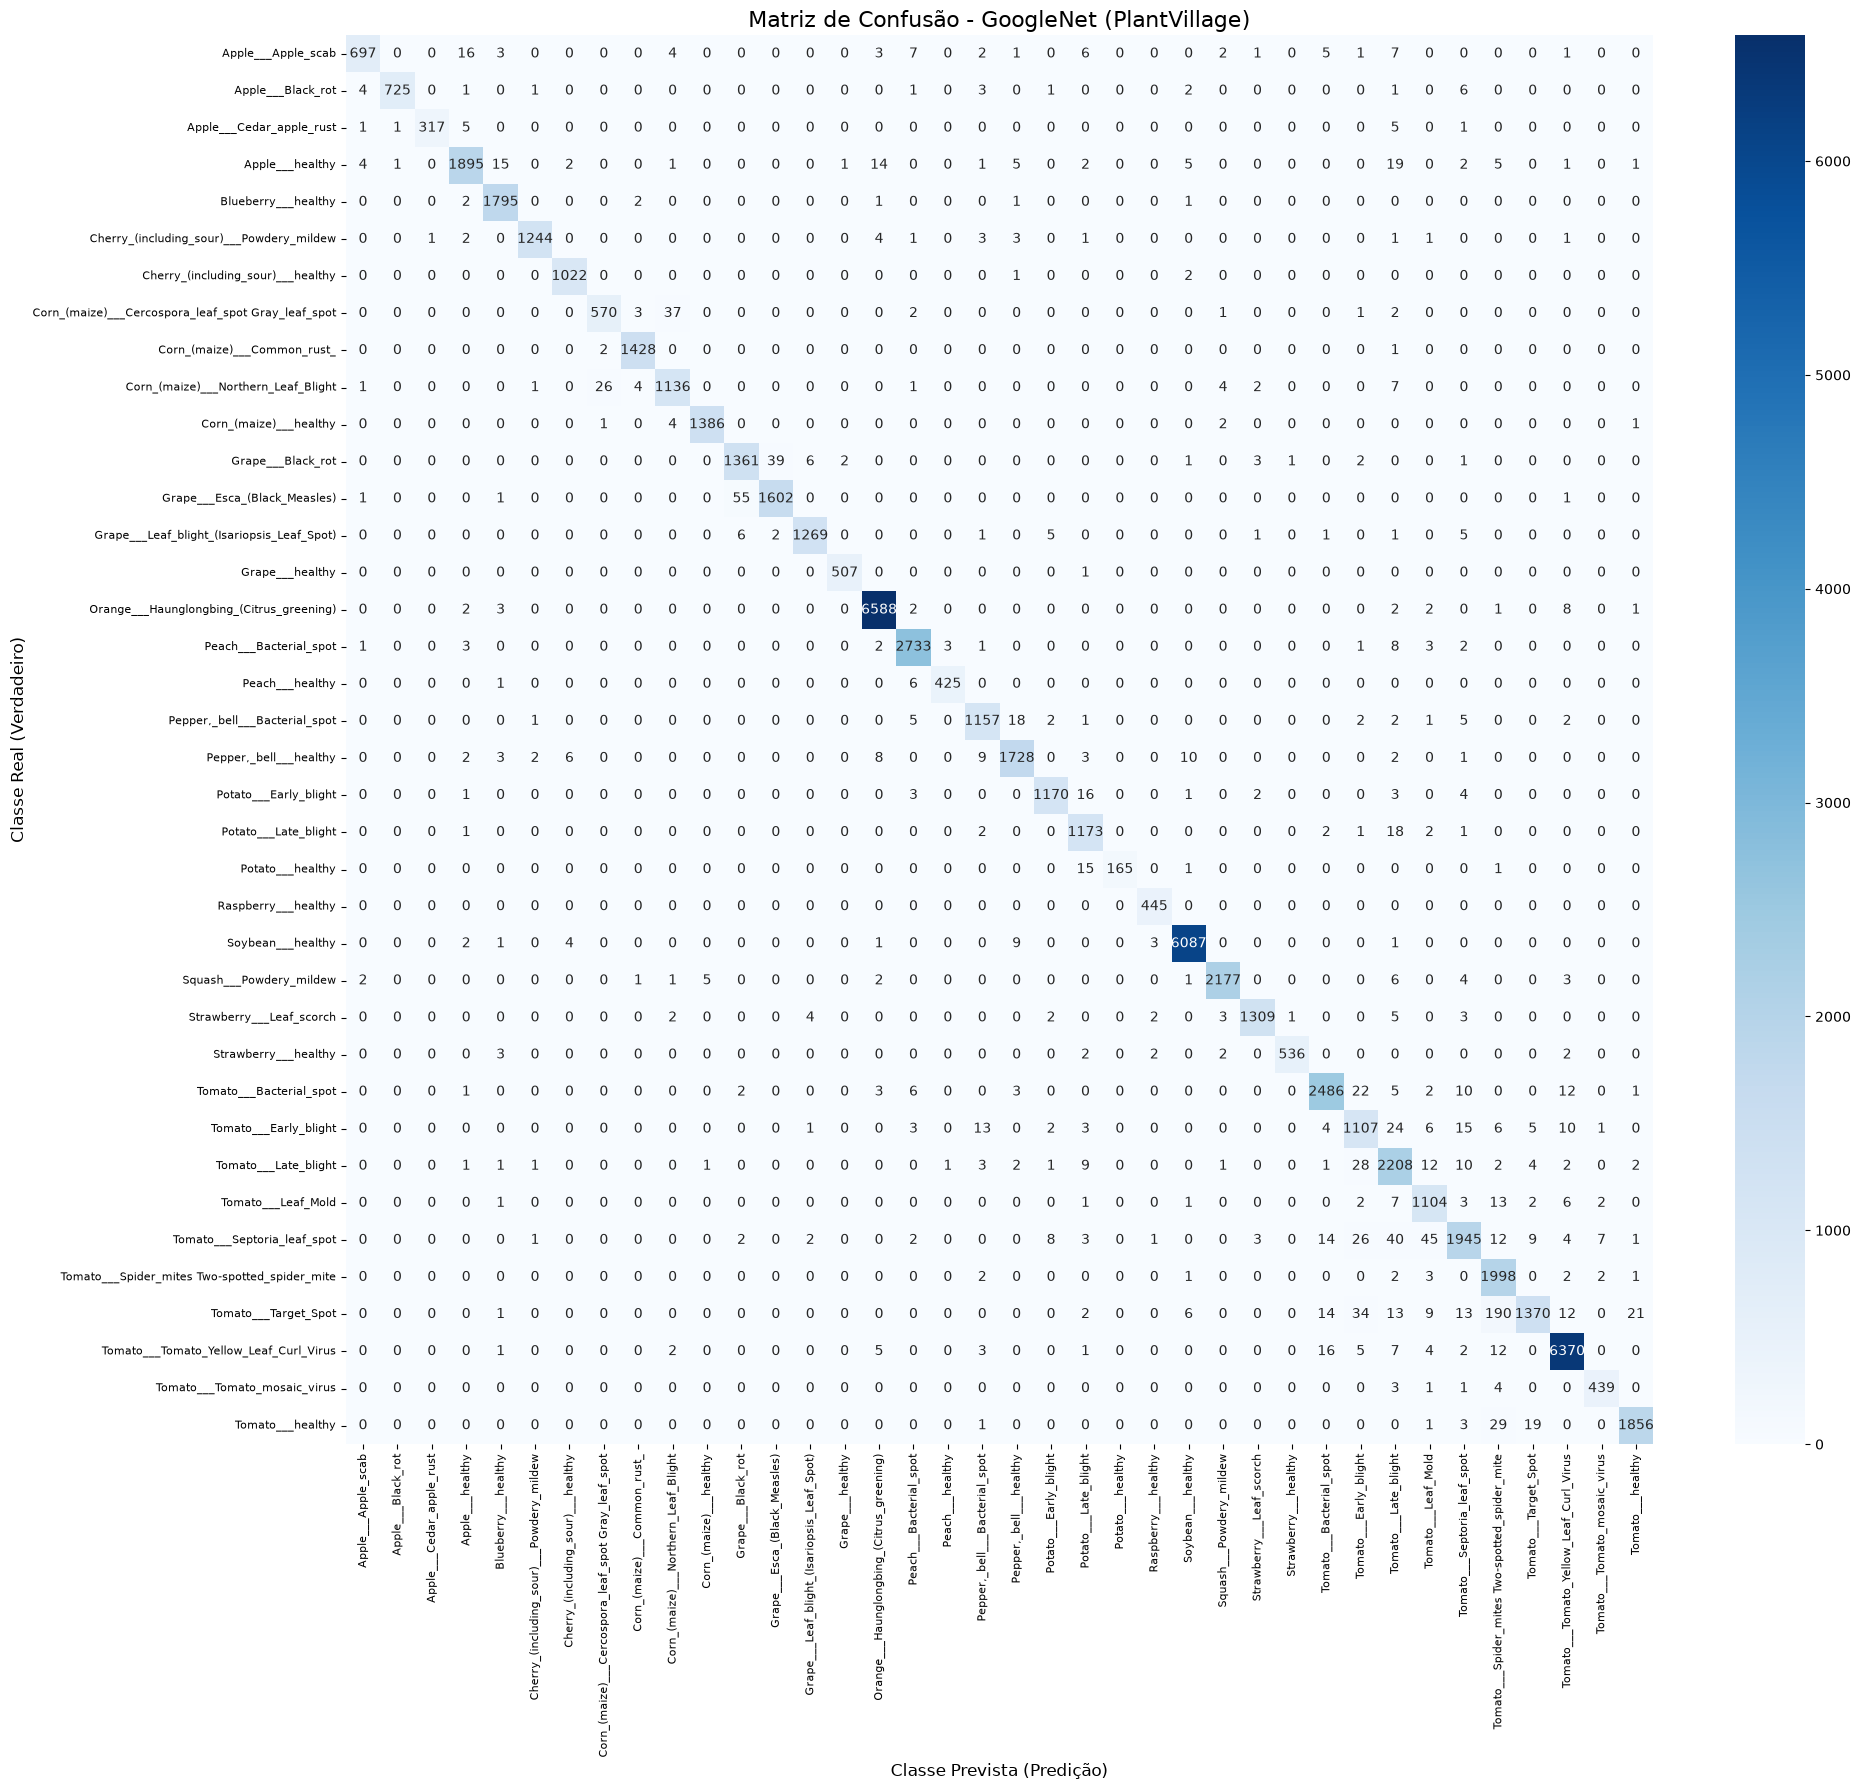

Matriz de confusão gerada e salva com sucesso!


In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotando a Matriz de Confusão de forma visual
plt.figure(figsize=(20, 18))

# Gerando o heatmap
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)

# Ajustes visuais para não sobrepor os textos
plt.xticks(rotation=90, fontsize=8) # Rotação e tamanho da fonte do eixo X
plt.yticks(rotation=0, fontsize=8) # Tamanho da fonte do eixo Y

plt.xlabel('Classe Prevista (Predição)', fontsize=12)
plt.ylabel('Classe Real (Verdadeiro)', fontsize=12)
plt.title('Matriz de Confusão - GoogleNet (PlantVillage)', fontsize=16)

# Ajusta o layout para não cortar os rótulos
plt.tight_layout()

# Salva a imagem em alta resolução
plt.savefig('matriz_confusao_googlenet_plantvillage.png', dpi=300)

# Mostra na tela
plt.show()

print('Matriz de confusão gerada e salva com sucesso!')